In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.semi_supervised import LabelSpreading, SelfTrainingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv('cleaned_dataset.csv')
df['target'] = (df['Status2'] == 1.0).astype(int) # Binary: Active vs Others


In [3]:
cols_to_drop = ['Status', 'Status2', 'SampleID', 'Typeofcomplaint', 'Check', 'filter_$']
data = df.drop(columns=cols_to_drop).fillna(df.median(numeric_only=True))

for col in data.select_dtypes(include=['object', 'string']).columns:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

X = data.drop(columns=['target'])
y = data['target']

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_train_semi = y_train_full.copy()
rng = np.random.RandomState(42)
y_train_semi[rng.rand(y_train_full.shape[0]) < 0.8] = -1 # Masking labels

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

In [5]:
lp_model = LabelSpreading(kernel='knn', n_neighbors=5, alpha=0.2)
lp_model.fit(X_train_scaled, y_train_semi)

,"kernel kernel: {'knn', 'rbf'} or callable, default='rbf'String identifier for kernel function to use or the kernel functionitself. Only 'rbf' and 'knn' strings are valid inputs. The functionpassed should take two inputs, each of shape (n_samples, n_features),and return a (n_samples, n_samples) shaped weight matrix.",'knn'
,"gamma gamma: float, default=20Parameter for rbf kernel.",20
,"n_neighbors n_neighbors: int, default=7Parameter for knn kernel which is a strictly positive integer.",5
,"alpha alpha: float, default=0.2Clamping factor. A value in (0, 1) that specifies the relative amountthat an instance should adopt the information from its neighbors asopposed to its initial label.alpha=0 means keeping the initial label information; alpha=1 meansreplacing all initial information.",0.2
,"max_iter max_iter: int, default=30Maximum number of iterations allowed.",30
,"tol tol: float, default=1e-3Convergence tolerance: threshold to consider the system at steadystate.",0.001
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [6]:
gpc = GaussianProcessClassifier(1.0 * RBF(1.0))
st_model = SelfTrainingClassifier(gpc, threshold=0.75, max_iter=5)
st_model.fit(X_train_scaled, y_train_semi)

,"estimator estimator: estimator objectAn estimator object implementing `fit` and `predict_proba`.Invoking the `fit` method will fit a clone of the passed estimator,which will be stored in the `estimator_` attribute... versionadded:: 1.6 `estimator` was added to replace `base_estimator`.",GaussianProce...ngth_scale=1))
,"threshold threshold: float, default=0.75The decision threshold for use with `criterion='threshold'`.Should be in [0, 1). When using the `'threshold'` criterion, a:ref:`well calibrated classifier ` should be used.",0.75
,"criterion criterion: {'threshold', 'k_best'}, default='threshold'The selection criterion used to select which labels to add to thetraining set. If `'threshold'`, pseudo-labels with predictionprobabilities above `threshold` are added to the dataset. If `'k_best'`,the `k_best` pseudo-labels with highest prediction probabilities areadded to the dataset. When using the 'threshold' criterion, a:ref:`well calibrated classifier ` should be used.",'threshold'
,"k_best k_best: int, default=10The amount of samples to add in each iteration. Only used when`criterion='k_best'`.",10
,"max_iter max_iter: int or None, default=10Maximum number of iterations allowed. Should be greater than or equalto 0. If it is `None`, the classifier will continue to predict labelsuntil no new pseudo-labels are added, or all unlabeled samples havebeen labeled.",5
,"verbose verbose: bool, default=FalseEnable verbose output.",False
,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ""1.0 * RBF(1.0)"" is used as default. Note thatthe kernel's hyperparameters are optimized during fitting. Also kernelcannot be a `CompoundKernel`.",1**2 * RBF(length_scale=1)
,"optimizer optimizer: 'fmin_l_bfgs_b', callable or None, default='fmin_l_bfgs_b'Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func' is the objective function to be maximized, which # takes the hyperparameters theta as parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the 'L-BFGS-B' algorithm from scipy.optimize.minimizeis used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are:: 'fmin_l_bfgs_b'",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that n_restarts_optimizer=0 implies that onerun is performed.",0
,"max_iter_predict max_iter_predict: int, default=100The maximum number of iterations in Newton's method for approximatingthe posterior during predict. Smaller values will reduce computationtime at the cost of worse results.",100
,"warm_start warm_start: bool, default=FalseIf warm-starts are enabled, the solution of the last Newton iterationon the Laplace approximation of the posterior mode is used asinitialization for the next call of _posterior_mode(). This can speedup convergence when _posterior_mode is called several times on similarproblems as in hyperparameter optimization. See :term:`the Glossary`.",False


In [7]:
y_pred_lp = lp_model.predict(X_test_scaled)
y_pred_st = st_model.predict(X_test_scaled)

In [8]:
model_names = ['Label Spreading', 'Self-Training GPC']
predictions = [y_pred_lp, y_pred_st]

In [9]:
metrics_list = []

for name, y_pred in zip(model_names, predictions):
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

In [10]:
metrics_df = pd.DataFrame(metrics_list).melt(id_vars='Model', var_name='Metric', value_name='Value')

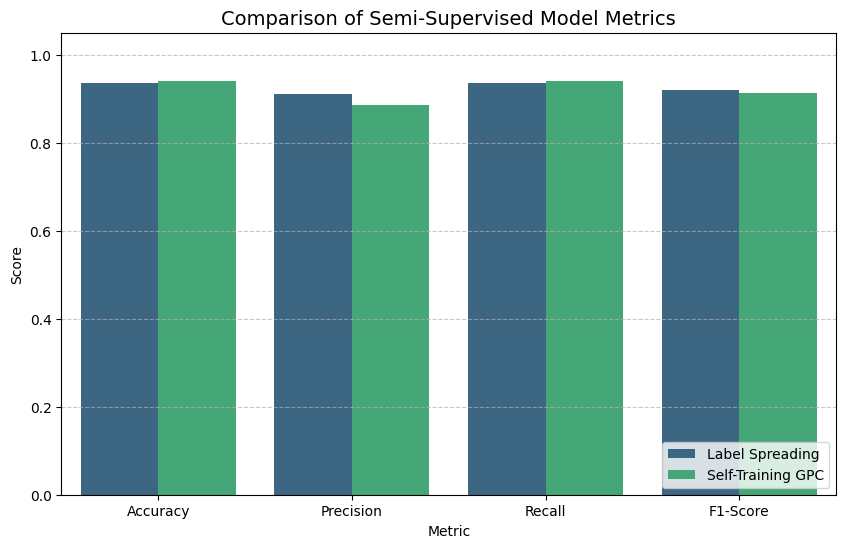

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Metric', y='Value', hue='Model', palette='viridis')
plt.title('Comparison of Semi-Supervised Model Metrics', fontsize=14)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

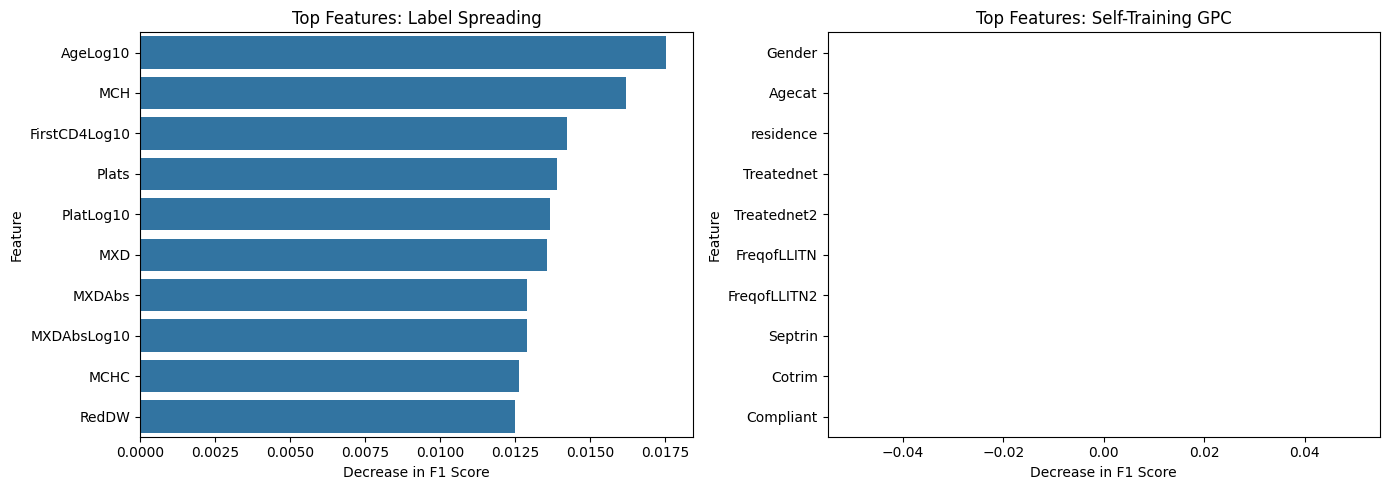

In [12]:
models = {
    "Label Spreading": lp_model,
    "Self-Training GPC": st_model.estimator_  # ← correct attribute name
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    
    result = permutation_importance(
        model, X_test_scaled, y_test,
        n_repeats=10, random_state=42, scoring='f1_weighted'
    )
    
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": result.importances_mean
    }).sort_values("Importance", ascending=False).head(10)
    
    sns.barplot(data=importance, x="Importance", y="Feature", ax=ax)
    ax.set_title(f"Top Features: {name}")
    ax.set_xlabel("Decrease in F1 Score")

plt.tight_layout()
plt.show()

In [13]:
import os
import joblib

# Persist trained objects so you can load them later without re-training.
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(scaler, os.path.join(model_dir, "scaler.joblib"))
joblib.dump(lp_model, os.path.join(model_dir, "label_spreading.joblib"))
joblib.dump(st_model, os.path.join(model_dir, "self_training_gpc.joblib"))
joblib.dump(X.columns.tolist(), os.path.join(model_dir, "feature_columns.joblib"))

print(f"Saved models and preprocessing artifacts to: {model_dir}/")

Saved models and preprocessing artifacts to: models/


In [14]:
label_encoders = {}
for col in data.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le  # Store the fitted encoder

In [15]:
import joblib
joblib.dump(label_encoders, 'label_encoders.joblib')

['label_encoders.joblib']

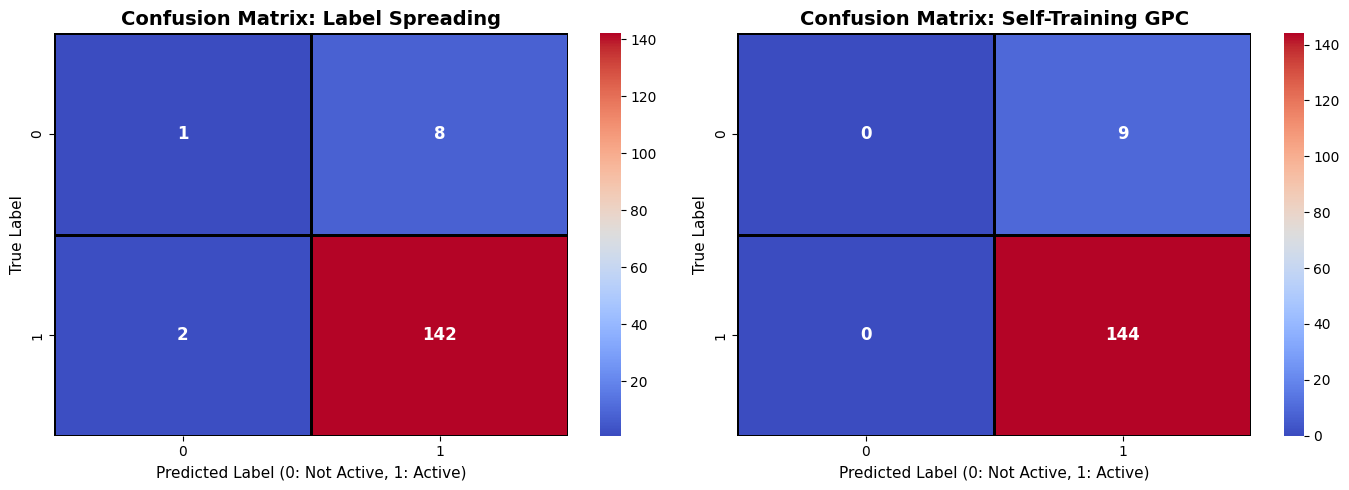

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, y_pred) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm',  
        ax=ax[i],
        cbar=True,         
        linewidths=1,      
        linecolor='black',
        annot_kws={"size": 12, "weight": "bold"}  
    )
    
    ax[i].set_title(f'Confusion Matrix: {name}', fontsize=14, weight='bold')
    ax[i].set_xlabel('Predicted Label (0: Not Active, 1: Active)', fontsize=11)
    ax[i].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
print("--- Accuracy Indication Summary ---")
print(pd.DataFrame(metrics_list).to_string(index=False))

--- Accuracy Indication Summary ---
            Model  Accuracy  Precision   Recall  F1-Score
  Label Spreading  0.934641   0.910588 0.934641  0.918968
Self-Training GPC  0.941176   0.885813 0.941176  0.912656
